In [482]:
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import numpy as np

import datetime

from numpy.random import choice

import logging
logger = logging.getLogger()
logger.setLevel(logging.WARNING)
logging.debug("test")

### Load data

In [2]:
path = 'data'
data = pd.DataFrame()
for file in os.listdir(path):
    df = pd.read_csv(os.path.join(path,file), sep=';')
    df['timestamp'] = pd.to_datetime(df['timestamp'], format="%Y-%m-%d %H:%M:%S")
    data = pd.concat([data,df])
data = data.sort_values(by=['timestamp']).reset_index(drop=True)

In [3]:
aisles = ['fruit', 'spices', 'dairy', 'drinks', 'checkout']
aisles

['fruit', 'spices', 'dairy', 'drinks', 'checkout']

### Get customer locations, times and durations as rows

In [4]:
plot_data = data.sort_values(by=['timestamp'])#.copy()
plot_data['day'] = plot_data['timestamp'].dt.dayofweek
idx = plot_data.groupby(['day', 'customer_no']).all().index
df_times = pd.DataFrame(index=idx)
df_durations = pd.DataFrame(index=idx)
df_locations = pd.DataFrame(index=idx)

max_sections = plot_data.groupby(['day', 'customer_no'])['location'].count().max()
for n in range(max_sections):
    df_times[n] = plot_data.groupby(['day','customer_no']).nth(n)['timestamp']
    
    df_locations[n] = plot_data.groupby(['day','customer_no']).nth(n)['location']
    
    if n>0:
        df_durations[n-1] = (df_times[n] - df_times[n-1]).dt.seconds
    
#df_durations

### Probability mass function for first aisle visited

In [5]:
# get probabilities for first aisle visited
first_aisle_proba = pd.DataFrame(index=aisles)

first_aisle_proba['all days'] = df_locations[0].value_counts() / df_locations[0].count()

for day in df_locations.index.levels[0]:
    first_aisle_proba[f'day {day}'] = df_locations.loc[day,0].value_counts() / df_locations.loc[day,0].count()

In [6]:
first_aisle_proba

,all days,day 0,day 1,day 2,day 3,day 4
fruit,0.377435,0.359364,0.393108,0.378184,0.368730,0.388079
spices,0.181464,0.195577,0.159634,0.163945,0.194137,0.193377
dairy,0.287576,0.284727,0.292546,0.301764,0.295114,0.263576
drinks,0.153526,0.160332,0.154712,0.156107,0.142020,0.154967
checkout,NaN,NaN,NaN,NaN,NaN,NaN


### Transition probabilities

#####  For all days, from each location to the next without consideration of time

In [9]:
# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
transition_matrix = pd.DataFrame(columns=aisles, index=aisles[:-1])
transition_matrix.index.rename('start aisle', inplace=True)
transition_matrix.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_locations.fillna(method='ffill', axis=1)
dummy_locations[999] = np.nan

# loop through the aisles, find the table indeces where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for a in aisles:#[:-1]:
    instances_a = np.where(dummy_locations==a)
    instances_next = (instances_a[0], instances_a[1] + 1)
    transition_matrix.loc[a] = pd.Series(dummy_locations.values[instances_next]).value_counts()


# the total number of transitions from each aisle is the sum along the rows
total_transitions = transition_matrix.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba = transition_matrix.div(total_transitions,axis=0)
transition_proba

/home/flann/.local/lib/python3.7/site-packages/pandas/core/ops/__init__.py:1115: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)


next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.019927,0.123395,0.233570,0.133550,0.489557
spices,0.149398,0.019100,0.317373,0.267923,0.246206
dairy,0.181557,0.187090,0.044057,0.213320,0.373975
drinks,0.217226,0.214939,0.026931,0.008384,0.532520
checkout,NaN,NaN,NaN,NaN,1.000000


In [10]:
transition_proba

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.019927,0.123395,0.233570,0.133550,0.489557
spices,0.149398,0.019100,0.317373,0.267923,0.246206
dairy,0.181557,0.187090,0.044057,0.213320,0.373975
drinks,0.217226,0.214939,0.026931,0.008384,0.532520
checkout,NaN,NaN,NaN,NaN,1.000000


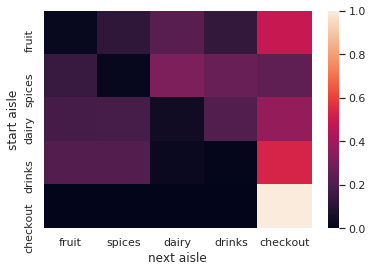

In [11]:
sns.heatmap(transition_proba.fillna(0));

#####  For individual days, from each location to the next without consideration of time

In [12]:
# calculate the transition matrix by day

# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
day_idx = ['all'] + list(range(5))
multi_idx = pd.MultiIndex.from_product([day_idx,aisles[:-1]], names=['day','start aisle'])
transition_matrix_by_day = pd.DataFrame(columns=aisles, index=multi_idx)
# transition_matrix_by_day.index.rename('start aisle', inplace=True)
transition_matrix_by_day.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_locations.copy()
dummy_locations[999] = np.nan

# loop through the aisles, find the table indices where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for day in day_idx:
    for a in aisles[:-1]:
        if day == 'all':
            key = day_idx[1:]
        else:
            key = day
        instances_a = np.where(dummy_locations.loc[key]==a)
        instances_next = (instances_a[0], instances_a[1] + 1)
        counts = pd.Series(dummy_locations.loc[key].values[instances_next]).value_counts()
        transition_matrix_by_day.loc[(day,a)] = counts


# the total number of transitions from each aisle is the sum along the rows
total_transitions_by_day = transition_matrix_by_day.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_by_day = transition_matrix_by_day.div(total_transitions_by_day,axis=0)
transition_proba_by_day

next aisle          fruit    spices      dairy    drinks  checkout
day start aisle                                                   
all fruit             NaN  0.125904   0.238319  0.136266  0.499511
    spices       0.152307       NaN   0.323553   0.27314     0.251
    dairy        0.189925  0.195713        NaN  0.223151  0.391211
    drinks       0.219062  0.216756  0.0271586       NaN  0.537023
0   fruit             NaN  0.121878   0.224775   0.12987  0.523477
    spices       0.159091       NaN   0.314171  0.290107  0.236631
    dairy         0.20202  0.205387        NaN  0.244669  0.347924
    drinks       0.233375  0.203262  0.0288582       NaN  0.534504
1   fruit             NaN  0.131148   0.237705  0.132172  0.498975
    spices       0.144092       NaN   0.354467  0.262248  0.239193
    dairy        0.184818  0.206821        NaN   0.20022  0.408141
    drinks       0.208976  0.211781  0.0238429       NaN    0.5554
2   fruit             NaN  0.117195   0.243996  0.126801  0.512008
    spices       0.146776       NaN   0.323731   0.26749  0.262003
    dairy        0.177618  0.201232        NaN  0.214579  0.406571
    drinks       0.237419  0.207742  0.0309677       NaN  0.523871
3   fruit             NaN  0.134486   0.225744  0.132565  0.507205
    spices       0.150633       NaN   0.322785  0.265823  0.260759
    dairy        0.201663  0.183992        NaN  0.218295   0.39605
    drinks       0.208763  0.225515  0.0283505       NaN  0.537371
4   fruit             NaN     0.125   0.258523  0.159091  0.457386
    spices       0.159898       NaN   0.305838  0.279188  0.255076
    dairy        0.184069  0.181916        NaN  0.238967  0.395048
    drinks       0.206651  0.233967   0.023753       NaN  0.535629

## Recalculate the transition matrix using a timestep of 1 minute

In [13]:
df_location_by_time = data.sort_values(by=['customer_no', 'timestamp'])
df_location_by_time['day'] = df_location_by_time['timestamp'].dt.dayofweek
entrance_time = df_location_by_time.groupby(['day', 'customer_no']).nth(0)['timestamp']
df_location_by_time = df_location_by_time.set_index(['day', 'customer_no'])
time_elapsed = df_location_by_time['timestamp'] - entrance_time
df_location_by_time['time_elapsed'] = time_elapsed.sort_index(level=1).values ### THIS IS A BIT HAIRY - add unique index ###
df_location_by_time = df_location_by_time.reset_index().set_index(['day', 'customer_no','time_elapsed'])['location']
df_location_by_time = df_location_by_time.unstack(-1).reindex(pd.timedelta_range('00S', '3600S', freq='60S'), axis=1) 
df_location_by_time = df_location_by_time.fillna(method='ffill', axis=1)
df_location_by_time

00:00:00  00:01:00  00:02:00  00:03:00  00:04:00  00:05:00  \
day customer_no                                                              
0   1              dairy     dairy  checkout  checkout  checkout  checkout   
    2              dairy     dairy     dairy  checkout  checkout  checkout   
    3              dairy     dairy  checkout  checkout  checkout  checkout   
    4              dairy     dairy     dairy     dairy  checkout  checkout   
    5             spices  checkout  checkout  checkout  checkout  checkout   
...                  ...       ...       ...       ...       ...       ...   
4   1506           dairy     dairy     dairy     dairy     dairy     dairy   
    1507           dairy     dairy  checkout  checkout  checkout  checkout   
    1508           dairy     dairy  checkout  checkout  checkout  checkout   
    1509          drinks    drinks    drinks    drinks    drinks    drinks   
    1510          spices    spices    spices    spices    spices    spices   

                 00:06:00  00:07:00  00:08:00  00:09:00  ...  00:51:00  \
day customer_no                                          ...             
0   1            checkout  checkout  checkout  checkout  ...  checkout   
    2            checkout  checkout  checkout  checkout  ...  checkout   
    3            checkout  checkout  checkout  checkout  ...  checkout   
    4            checkout  checkout  checkout  checkout  ...  checkout   
    5            checkout  checkout  checkout  checkout  ...  checkout   
...                   ...       ...       ...       ...  ...       ...   
4   1506            dairy     dairy     dairy     dairy  ...     dairy   
    1507         checkout  checkout  checkout  checkout  ...  checkout   
    1508         checkout  checkout  checkout  checkout  ...  checkout   
    1509           drinks    drinks    drinks    drinks  ...    drinks   
    1510           spices    spices    spices    spices  ...    spices   

                 00:52:00  00:53:00  00:54:00  00:55:00  00:56:00  00:57:00  \
day customer_no                                                               
0   1            checkout  checkout  checkout  checkout  checkout  checkout   
    2            checkout  checkout  checkout  checkout  checkout  checkout   
    3            checkout  checkout  checkout  checkout  checkout  checkout   
    4            checkout  checkout  checkout  checkout  checkout  checkout   
    5            checkout  checkout  checkout  checkout  checkout  checkout   
...                   ...       ...       ...       ...       ...       ...   
4   1506            dairy     dairy     dairy     dairy     dairy     dairy   
    1507         checkout  checkout  checkout  checkout  checkout  checkout   
    1508         checkout  checkout  checkout  checkout  checkout  checkout   
    1509           drinks    drinks    drinks    drinks    drinks    drinks   
    1510           spices    spices    spices    spices    spices    spices   

                 00:58:00  00:59:00  01:00:00  
day customer_no                                
0   1            checkout  checkout  checkout  
    2            checkout  checkout  checkout  
    3            checkout  checkout  checkout  
    4            checkout  checkout  checkout  
    5            checkout  checkout  checkout  
...                   ...       ...       ...  
4   1506            dairy     dairy     dairy  
    1507         checkout  checkout  checkout  
    1508         checkout  checkout  checkout  
    1509           drinks    drinks    drinks  
    1510           spices    spices    spices  

[7445 rows x 61 columns]

In [14]:
# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
transition_matrix_minutely = pd.DataFrame(columns=aisles, index=aisles[:-1])
transition_matrix_minutely.index.rename('start aisle', inplace=True)
transition_matrix_minutely.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_location_by_time.copy()
dummy_locations["23:59:59"] = np.nan

# loop through the aisles, find the table indeces where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for a in aisles:#[:-1]:
    instances_a = np.where(dummy_locations==a)
    instances_next = (instances_a[0], instances_a[1] + 1)
    transition_matrix_minutely.loc[a] = pd.Series(dummy_locations.values[instances_next]).value_counts()


# the total number of transitions from each aisle is the sum along the rows
total_transitions = transition_matrix_minutely.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_minutely = transition_matrix_minutely.div(total_transitions,axis=0).fillna(0)
transition_proba_minutely

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.608945,0.049235,0.093196,0.053287,0.195336
spices,0.087202,0.427459,0.185247,0.156384,0.143708
dairy,0.047794,0.049250,0.748355,0.056155,0.098446
drinks,0.086873,0.085958,0.010770,0.603434,0.212965
checkout,0.000000,0.000000,0.000000,0.000000,1.000000


In [15]:
# calculate the transition matrix by day

# set up a dataframe for the transition matrix
# should have a column and a row for each aisle
day_idx = ['all'] + list(range(5))
multi_idx = pd.MultiIndex.from_product([day_idx,aisles], names=['day','start aisle'])
transition_matrix_by_day_minutely = pd.DataFrame(columns=aisles, index=multi_idx)
# transition_matrix_by_day_minutely.index.rename('start aisle', inplace=True)
transition_matrix_by_day_minutely.columns.rename('next aisle', inplace=True)

# make a temporary version of the locations dataframe
# this should have an extra column to avoid an indexing error later
dummy_locations = df_location_by_time.copy()
dummy_locations["23:59:59"] = np.nan

# loop through the aisles, find the table indices where that aisle appears
# the "next aisle" is the aisle named in the following column of the same row 
for day in day_idx:
    for a in aisles:
        if day == 'all':
            key = day_idx[1:]
        else:
            key = day
        instances_a = np.where(dummy_locations.loc[key]==a)
        instances_next = (instances_a[0], instances_a[1] + 1)
        counts = pd.Series(dummy_locations.loc[key].values[instances_next]).value_counts()
        transition_matrix_by_day_minutely.loc[(day,a)] = counts


# the total number of transitions from each aisle is the sum along the rows
total_transitions_by_day = transition_matrix_by_day_minutely.sum(axis=1)

# calculate the probability of each transition by dividing by the total_transitions from each starting aisle
transition_proba_by_day_minutely = transition_matrix_by_day_minutely.div(total_transitions_by_day,axis=0)
transition_proba_by_day_minutely = transition_proba_by_day_minutely.fillna(0)
transition_proba_by_day_minutely

next aisle          fruit    spices     dairy    drinks  checkout
day start aisle                                                  
all fruit        0.608945  0.049235  0.093196  0.053287  0.195336
    spices       0.087202  0.427459  0.185247  0.156384  0.143708
    dairy        0.047794  0.049250  0.748355  0.056155  0.098446
    drinks       0.086873  0.085958  0.010770  0.603434  0.212965
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
0   fruit        0.639149  0.043980  0.081110  0.046864  0.188897
    spices       0.088740  0.442207  0.175242  0.161820  0.131991
    dairy        0.048309  0.049114  0.760870  0.058508  0.083199
    drinks       0.090865  0.079140  0.011236  0.610650  0.208109
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
1   fruit        0.585034  0.054422  0.098639  0.054847  0.207058
    spices       0.086133  0.402239  0.211886  0.156761  0.142980
    dairy        0.047218  0.052839  0.744519  0.051152  0.104272
    drinks       0.086227  0.087384  0.009838  0.587384  0.229167
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
2   fruit        0.597759  0.047141  0.098145  0.051005  0.205951
    spices       0.082881  0.435321  0.182804  0.151046  0.147947
    dairy        0.046183  0.052322  0.739989  0.055793  0.105713
    drinks       0.094214  0.082437  0.012289  0.603175  0.207885
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
3   fruit        0.608057  0.052711  0.088479  0.051958  0.198795
    spices       0.088279  0.413947  0.189169  0.155786  0.152819
    dairy        0.050129  0.045736  0.751421  0.054264  0.098450
    drinks       0.086400  0.093333  0.011733  0.586133  0.222400
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000
4   fruit        0.610332  0.048708  0.100738  0.061993  0.178229
    spices       0.089552  0.439943  0.171286  0.156361  0.142857
    dairy        0.047004  0.046454  0.744640  0.061023  0.100880
    drinks       0.077713  0.087986  0.008933  0.623939  0.201429
    checkout     0.000000  0.000000  0.000000  0.000000  1.000000

### Markov Chain

##### select initial state

In [16]:
ts = datetime.timedelta(0,0)
initial_choice_proba = first_aisle_proba['all days'].dropna()
current_state = choice(initial_choice_proba.index, 1, p=initial_choice_proba)[0]
print(f"{ts} {current_state}")
while current_state != 'checkout':
    proba = transition_proba_minutely.loc[current_state].dropna()
    current_state = choice(proba.index, 1, p=proba)[0]
    ts += datetime.timedelta(0,60)
    print(f"{ts} {current_state}")

0:00:00 drinks
0:01:00 drinks
0:02:00 drinks
0:03:00 drinks
0:04:00 drinks
0:05:00 fruit
0:06:00 checkout


In [136]:
class Customer:
    """
    Class representing a customer in the DOODL supermarket!
    
    Attributes:
        entry_time (datetime.datetime): the time at which the customer enters the supermarket
        initial_pmf (pandas.Series): probability mass function for the customer's initial state,
        i.e. which aisle the customer will go to first
        transition_matrix (pandas.DataFrame): transition matrix containing the probability of where the 
        customer will head in the next minute, base on where they are now
        exit_state (string): the state at which the customer exits the simulation
    """
    
    
    def __init__(self, number, initial_pmf, transition_matrix):
        
        assert np.all(initial_pmf.index.isin(transition_matrix.index))
        self.initial_pmf = initial_pmf
        self.transition_matrix = transition_proba_minutely
        
        self.number = number
        self.__set_initial_state__()
        self.current_state = self.__get_initial_state__()
        
            
    def __repr__(self):
        return f"Customer {self.number}" #and history {', '.join(self.history)}
    
    def __str__(self):
        return f"Customer {self.number}" #", entry at {self.entry_time}, {self.initial_state}"
        
    def __set_initial_state__(self):
        """
        randomly selects an initial state from initial_pmf
        """
        self.initial_state  = choice(self.initial_pmf.index, 1, p=self.initial_pmf)[0]
        
    def __get_initial_state__(self):
        return self.initial_state
        

    @property
    def __record__(self):
        return self.current_state
    
    def __iter__(self):
        return self
    
    def __next__(self):
        record = self.__record__
        tm = self.transition_matrix.loc[self.current_state].dropna()
        self.current_state = choice(tm.index, 1, p=tm)[0]
        return record


In [137]:
class JoeCustomer(Customer):
    """
    Customer with initial_pmf and transition_matrix based on average of all customers
    """
    
    
    def __init__(self, number):
        
        self.initial_pmf = initial_choice_proba
        self.transition_matrix = transition_matrix
        
        assert np.all(self.initial_pmf.index.isin(self.transition_matrix.index))
        
        
        self.number = number
        self.__set_initial_state__()
        self.current_state = self.__get_initial_state__()

In [139]:
j = JoeCustomer(0)
j

Customer 0

In [122]:
initial_pmf = initial_choice_proba
transition_matrix = transition_proba_minutely

assert np.all(initial_pmf.index.isin(transition_matrix.index))
aisles_dict = {i:a for i,a in enumerate(transition_matrix.index)}

In [123]:
# default_dtype = Customer._default_dtype

def get_next_location(gen):
    try:
        return next(gen)
    except StopIteration:
#         return np.ndarray(0, dtype=default_dtype)
        return None

In [124]:
initial_choice_proba = first_aisle_proba['all days'].dropna()

entry_time = datetime.datetime.utcnow()

# c1 = Customer(0, entry_time, initial_choice_proba, transition_proba_minutely)
c1 = Customer(0, initial_choice_proba, transition_proba_minutely)
c1

Customer 0

In [125]:
get_next_location(c1)

'dairy'

In [126]:
# default_dtype = Customer._default_dtype

def yield_customer_locations(customer_list):
    for i, c in customer_list.items():
        try:
            yield np.array([(i, next(c))], dtype=[('customer_no', 'int32'), ('location', 'U10')])
        except StopIteration:
            pass
        

In [127]:
new_df = pd.DataFrame()

customers = {}
opening_time = pd.to_datetime("01/01/2020 09:00")
time_step = datetime.timedelta(0,60)
for i in range(10):
    time = opening_time# + time_step * i
    
#     customers[i] = (Customer(i, time, initial_choice_proba, transition_proba_minutely))
    customers[i] = (Customer(i, initial_choice_proba, transition_proba_minutely))

exit_state = "checkout"
checked_out = np.array([-999])

In [128]:
time = 0
while customers:
    gen = yield_customer_locations(customers)
    for g in gen:
        new_records = pd.DataFrame(g)
        new_records['datetime'] = time
        new_df = new_df.append(new_records, ignore_index=True)
        leaving = new_records.loc[new_records['location']==exit_state, "customer_no"].values
        checked_out = np.concatenate((checked_out,leaving))
        
    for n in checked_out:
        customers.pop(n, None)
    time += 1
    
#     customers = [c for c in customers if c.number not in checked_out]
new_df

,customer_no,location,datetime
0,0,fruit,0
1,1,dairy,0
2,2,spices,0
3,3,spices,0
4,4,fruit,0
...,...,...,...
58,6,dairy,8
59,6,dairy,9
60,6,drinks,10
61,6,fruit,11


In [198]:
# a day in the life of a supermarket

def yield_customer_locations(customer_list):
    for i, c in customer_list.items():
        try:
            yield np.array([(i, next(c))], dtype=[('customer_no', 'int32'), ('location', 'U10')])
        except StopIteration:
            pass
        


# opening_time = pd.to_datetime("01/01/2020 09:00")
# closing_time = pd.to_datetime("01/01/2020 17:00")
# time_step = datetime.timedelta(0,60)

date = pd.to_datetime("2020-02-27")
opening_time = datetime.timedelta(days = 9*1/24)
closing_time = datetime.timedelta(days = 10*1/24)

time_step = datetime.timedelta(0,60)
time_range = pd.timedelta_range(start=opening_time, end=closing_time, freq=time_step)

turnstile_counter = 0
exit_state = "checkout"

records_df = pd.DataFrame()
checked_out = np.array([-999])

for time in time_range:
    n_new_customers = 2
    
    for i in range(n_new_customers):
        
        customers[turnstile_counter] = JoeCustomer(turnstile_counter)
        turnstile_counter += 1
    
    recs = yield_customer_locations(customers)
    for r in recs:
        new_records = pd.DataFrame(r)
        new_records['timestamp'] = time
        records_df = records_df.append(new_records, ignore_index=True)
        leaving = new_records.loc[new_records['location']==exit_state, "customer_no"].values
        checked_out = np.concatenate((checked_out,leaving))

    for n in checked_out:
        customers.pop(n, None)
    
records_df['timestamp'] = records_df['timestamp'] + date
#     customers = [c for c in customers if c.number not in checked_out]
records_df

,customer_no,location,timestamp
0,18,dairy,2020-02-27 09:00:00
1,86,fruit,2020-02-27 09:00:00
2,94,fruit,2020-02-27 09:00:00
3,96,dairy,2020-02-27 09:00:00
4,98,dairy,2020-02-27 09:00:00
...,...,...,...
899,114,dairy,2020-02-27 10:00:00
900,115,fruit,2020-02-27 10:00:00
901,118,drinks,2020-02-27 10:00:00
902,120,dairy,2020-02-27 10:00:00


In [473]:
class SuperMarket:
    """
    Class representing a supermarket in which customers can shop

    _______
    params:
    aisles (list): list of aisle names in the supermarket
    exit_state (string): state at which customers should leave the supermarket
    customers (list): list of Customer objects to be included in the supermarket
    opening_time (string): time recognisable by pandas.to_datetime at which supermarket opens
    closing_time (string): time recognisable by pandas.to_datetime at which supermarket closes
    time_step (int): time step in seconds (default 60 seconds)
    default_transition_matrix (pandas.DataFrame):
    default_initial_pmf (pandas.Series):

    _______
    attributes:
    records (...): movement records for all customers that have been in the supermarket
    turnstile_counter (int): the number of customers that have passed through the supermarket

    _______
    methods:
    add_customer
    remove_customer
    track_customer
    move_time
    save_records

    """
    customers = {}
    turnstile_counter = 0    
    records_df = pd.DataFrame()
    
    at_checkout = []
    checkout_records = pd.DataFrame()
    queuing_times = pd.DataFrame()

    def __init__(
        self, aisles, n_checkouts=1, checkout_rate=0.5,
        exit_state="checkout", customers=None,
        opening_time="09:00", closing_time="17:00", time_step=60, 
        default_transition_matrix=None,
        default_initial_pmf=None,
    ):
        self.aisles = aisles
        self.exit_state = exit_state
        if customers != None:
            self.customers = customers
        self.opening_time = pd.to_datetime(opening_time).time()
        self.closing_time = pd.to_datetime(closing_time).time()
        self.time_step = datetime.timedelta(0,time_step)
        
        assert n_checkouts > 0 and checkout_rate > 0
        self.n_checkouts = n_checkouts
        self.checkout_rate = checkout_rate


    def __repr__():
        return "I am a SuperMarket"

    
    def choose_customer_type(self, time, day):
        """
        Select the customer class to choose based on time and day
        """
#         if not isinstance(transition_matrix, pd.DataFrame):
#             if isinstance(self.default_transition_matrix, pd.DataFrame):
#                 transition_matrix = self.default_transition_matrix
#             else:
#                 raise Exception('No transition matrix found.')

#         if not isinstance(initial_pmf, pd.DataFrame):
#             if isinstance(self.default_initial_pmf, pd.DataFrame):
#                 initial_pmf = self.default_initial_pmf
#             else:
#                 raise Exception('No initial probability mass function found.')
                
        ...
        
        return JoeCustomer

    def add_customers(self, n_customers, customer_class=JoeCustomer, 
                      transition_matrix=None, initial_pmf=None,
    ):
        """
        Add n new customers to the supermarket
        """
                
        for n in range(n_customers):
            
            self.customers[self.turnstile_counter] = customer_class(self.turnstile_counter)
            self.queuing_times.loc[self.turnstile_counter,"time"] = self.time_step * 0
            self.turnstile_counter += 1

    def get_n_new_customers(self):
        """
        Choose the number of new customers that should be added in the current timestep
        """
        ...
        return 2
    
    def yield_customer_locations(self, customer_list):
        """
        Get the new locations for every customer in the supermarket
        """
        for i, c in customer_list.items():
            try:
                yield np.array([(i, next(c))], dtype=[('customer_no', 'int32'), ('location', 'U10')])
            except StopIteration:
                pass        
            
    def append_records(self, time):
        """
        Get customer records for the current timestep and append them to the supermarket records df
        """
        recs = self.yield_customer_locations(self.customers)

        self.new_records = np.array([r for r in recs]).reshape(-1)
        self.new_records = pd.DataFrame(self.new_records, index=range(len(self.new_records)))
        self.new_records['timestamp'] = time

        self.records_df = self.records_df.append(self.new_records, ignore_index=True)
            
    def work_checkout(self):
        """
        Operate the checkouts so the good people can go home and get on with their lives.
        If self.checkout_rate < 1, use a Binomial distribution with trial number equal to
        the number of open checkouts to sample the number of customers that get to leave 
        each minute.
        If self.checkout_rate >= 1, that number of customers are processed from each checkout
        every minute
        """
        if self.checkout_rate < 1:
            max_processed = np.random.binomial(self.n_checkouts, self.checkout_rate)
        else:
            max_processed = self.checkout_rate
        logging.debug(f"Max of {max_processed} customers may be checked out")
            
        leaving = []
        n_processed = 0
        logging.debug(f"currently at checkout: {self.at_checkout}")
        
        for cust in self.at_checkout:
            if n_processed >= max_processed:
                break
            leaving.append(cust)
            self.customers.pop(cust) # could use None as second argument 
            n_processed += 1
                
        logging.debug(f"{n_processed} customers checked out: {leaving}")
        for cust in leaving:
            self.at_checkout.remove(cust)

        self.queuing_times.loc[self.at_checkout,'time'] += self.time_step 
        
        
    def day_in_the_life(self, date):
        """
        Simulate a day's shopping

        Return a dataframe with the day's customer records
        """
        # initialise records and containers
        checked_out = np.array([-999])
        
        ot = datetime.timedelta(days=self.opening_time.hour*1/24, seconds=self.opening_time.minute*60)
        ct = datetime.timedelta(days=self.closing_time.hour*1/24, seconds=self.closing_time.minute*60)
        time_range = pd.timedelta_range(ot, ct, freq=self.time_step)
        
        
        for time in time_range:
            logging.debug(f"Time is {time}")
            
            n_new_customers = self.get_n_new_customers()
            customer_type = self.choose_customer_type(time, date.dayofweek)

            self.add_customers(n_new_customers, customer_type)

            self.append_records(time)
            
            new_at_checkout = self.new_records.loc[self.new_records['location']==exit_state, 
                                                   "customer_no"].tolist()
            new_at_checkout = [n for n in new_at_checkout if n not in self.at_checkout]
            logging.debug(f"new to checkout {new_at_checkout}")
            
            self.at_checkout += new_at_checkout
            self.work_checkout()
            
            self.checkout_records.loc[time,"queue_length"] = len(self.at_checkout)
        
        ### maybe call this datetime to avoid confusion with the dateless version?
        self.records_df['datetime'] = self.records_df['timestamp'] + date

        return records_df

In [483]:
logger.setLevel(logging.WARNING)

In [484]:
doodl = SuperMarket(aisles=aisles, n_checkouts=2, exit_state="checkout")

In [486]:
date = pd.to_datetime("2020-02-27")
%time records_df = doodl.day_in_the_life(date)

CPU times: user 1min 56s, sys: 66.6 ms, total: 1min 56s
Wall time: 1min 55s


In [487]:
records_df

,customer_no,location,timestamp
0,18,dairy,2020-02-27 09:00:00
1,86,fruit,2020-02-27 09:00:00
2,94,fruit,2020-02-27 09:00:00
3,96,dairy,2020-02-27 09:00:00
4,98,dairy,2020-02-27 09:00:00
...,...,...,...
899,114,dairy,2020-02-27 10:00:00
900,115,fruit,2020-02-27 10:00:00
901,118,drinks,2020-02-27 10:00:00
902,120,dairy,2020-02-27 10:00:00


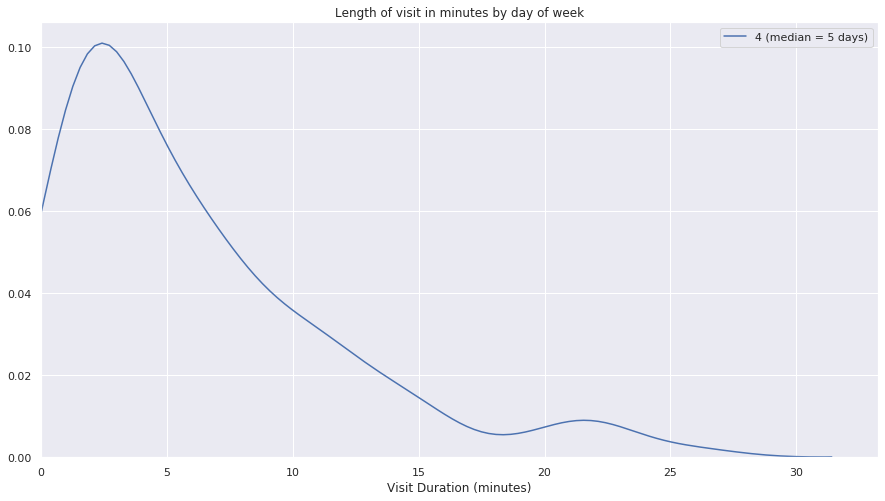

In [149]:
plot_data = records_df.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
plot_data['time_window'] = data['timestamp'].dt.floor('60T').dt.time
entry = plot_data.groupby(['customer_no','day'])['timestamp'].min()
exit = plot_data.groupby(['customer_no','day'])['timestamp'].max()
time_spent = exit - entry
duration = time_spent.rename('Visit Duration (minutes)').dt.seconds/60
plot_data = duration.reset_index() #.rename(columns={'timestamp':'duration'})

fig, ax = plt.subplots(figsize=(15,8))
# for day in ['Monday','Tuesday','Wednesday','Thursday','Friday']:
#     df = plot_data[plot_data['day']==day]
df = plot_data
label = "{} (median = {:.0f} days)".format(day, df['Visit Duration (minutes)'].median())
sns.distplot(a=df['Visit Duration (minutes)'], ax=ax, label=label, 
             hist=False,
#                 clip=(0,60),
#                  kde=False,
            );
ax.legend();
title = "Length of visit in minutes by day of week"
ax.set_title(title);
ax.set_xlim(0,None);

# median_table = plot_data.groupby('day')['Visit Duration (minutes)'].median().rename('Median duration')
# median_table = median_table.loc[['Monday','Tuesday','Wednesday','Thursday','Friday']]
# table = ax.table(cellText = median_table.values.reshape(-1,1),
#                  rowLabels=median_table.index, colWidths=[0.1],
#                  loc="right", #bbox=
#                  );



In [863]:
time_range = pd.timedelta_range('00S', '3600S', freq='60S')
customer_logs = pd.DataFrame()

# loop through times
for t in time_range:
    
#     at each time introduce a randomly chosen number of customers
    n = np.random.normal(2.8, 0.4, size=1).round().astype(int)
    
    # generate customers and add to container
    
    # get locations of customers and add to dataframe
    
    # remove any customers that have reached the checkout
    
    